<a href="https://colab.research.google.com/github/Alle84fr/aulas_Kin/blob/main/AvaliacaoParcial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'04-Criando a Arquitetura de Negócio e Operações - Pizzaria.gslides'
 12_grupo6.gsheet
 15_aquitetura_neg_grupo6.gsheet
 16_DFD_grupo6.gsheet
 17_Análise_eventos_grupo6.gsheet
 18_descricao_processos_grupo6.gsheet
 19_regras_negocio.gsheet
'2024-1-ADS1AN-Soft Skills-Presencial-ANDREA VOLANTE COSTA.gdoc'
'2025-02-24_10-01-08 - Alessandra 2401151 - erros.mp4'
 2025-10-23_13-55-18.mp4
 2025-10-23_15-54-44.mp4
 20_grupo6.gsheet
 20_modelo_conc_grupo6.gsheet
'22_ requis_sistem_grupo6.gdoc'
 22_requis_sist_grupo6.gsheet
'23_matriz de rast_grupo6.gsheet'
'4a. Glossário - Turma 6 - ADS 2A M.docx'
 6082-dados.gsheet
 9760429-sd_426_226_25fps.mp4
'AcademyCloudFoundations_Module_01 (1).gdoc'
'AcademyCloudFoundations_Module_01 (2).gdoc'
'AcademyCloudFoundations_Module_01 (3).gdoc'
 AcademyCloudFoundations_Module_01.gdoc
 ADS_A_manha_grupo6_provaFinal.gsheet
 a.gdoc


In [ ]:
!pip install gdown
!gdown "https://drive.google.com/content/drive/MyDrive/trabalho_colab_ale/latencia_sistemas_cloud (1).csv

/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
df=pd.read_csv('/content/drive/MyDrive/Alessandra_2401151/latencia_sistemas_cloud.csv',sep=",",encoding="latin1", header=0)

In [ ]:


print(df)

                 timestamp provider          region  latency_ms  \
0      2026-04-01 00:00:00      GCP       sa-east-1  103.370307   
1      2026-04-01 00:01:00      AWS  ap-northeast-1   23.110000   
2      2026-04-01 00:02:00      GCP       us-east-1   14.310000   
3      2026-04-01 00:03:00      GCP       sa-east-1  110.863725   
4      2026-04-01 00:04:00      AWS       us-east-1   12.930000   
...                    ...      ...             ...         ...   
14995  2026-04-11 09:55:00      GCP       sa-east-1   94.374484   
14996  2026-04-11 09:56:00      AWS  ap-northeast-1   28.130000   
14997  2026-04-11 09:57:00    Azure       eu-west-1   12.940000   
14998  2026-04-11 09:58:00      AWS       eu-west-1    4.360000   
14999  2026-04-11 09:59:00      AWS       sa-east-1  123.036416   

       throughput_mbps  error_rate  
0               860.43           0  
1               358.70           0  
2               533.34           0  
3               980.33           0  
4         

Fase 1: Diagnóstico Inicial (Estatística Descritiva)

Entender o comportamento dos dados.
1. Sumário Estatístico:

 1.1. Calcule média

 1.2. Mediana

 1.3. Desvio padrão

 1.4. Quartis (Q1, Q3)

 1.5. Coeficiente de Variação (CV) da latência

 Para cada provedor (AWS, Azure, GCP).

 2. Visualização:

 Crie um Histograma e um Boxplot da latência.

 Identifique visualmente a presença de outliers e comente sobre a simetria da distribuição.


In [ ]:
quant = len(df["latency_ms"])

media = np.mean(df["latency_ms"])

mediana = np.median(df["latency_ms"])

varianca = np.var(df["latency_ms"])

desvio_padrao = np.std(df["latency_ms"])

minimo = np.min(df["latency_ms"])

maximo = np.max(df["latency_ms"])

amplitude = (maximo) - (minimo)

Q1 = np.percentile(df["latency_ms"], 25)

Q3 = np.percentile(df["latency_ms"], 75)

Q2_amplitude = (Q3) - (Q1)

coeficinete_var = desvio_padrao / media

outLier_base = Q1 - (1.5 * Q2_amplitude)

outLier_topo = Q3 + (1.5 * Q2_amplitude)

mu = np.mean((df["latency_ms"] - media) **4)

curtose = mu / ((desvio_padrao**4) - 3)

In [ ]:
print(f"""
média: {media:.3f}
mediana: {mediana:.3f}
desvio padrão: {desvio_padrao:.3f}
Quartis:
  Q1: {Q1:.3f}
  Q2, amplitude: {Q2_amplitude:.3f}
  Q3: {Q3:.3f}
coeficiente: {coeficinete_var:.3f}
minimo: {minimo:.3f}
máximo: {maximo:.3f}
out_min: {outLier_base:.3f}
out_max: {outLier_topo:.3f}
""")


média: 32.947
mediana: 15.150
desvio padrão: 34.329
Quartis:
  Q1: 9.820
  Q2, amplitude: 51.323
  Q3: 61.143
coeficiente: 1.042
minimo: 2.020
máximo: 161.565
out_min: -67.164
out_max: 138.127



Foram analisados 15.000 registros, entre AWS, Azure e GCP.

A latência mínima real de 2.020 milesegundos, considerada excelente. A mediana de 15.150 ms indica que a metade das conexões são extremamente rápidas.

Desvio Padrão é de 34.329 ms,mostrando uma alta volatidade, com outlier chegando até 161.565 ms.

Embora outlier, ele ainda se enquadra em um padrão aceitável para a maioria das aplicações, não sendo considerado um serviço 'ruim'.



Latência de rede é o atraso na comunicação da rede. Ela mostra o tempo que os dados demoram para serem transferidos pela rede. Redes com atraso ou espera maior têm alta latência, enquanto redes com tempos de resposta rápidos têm baixa latência. <https://aws.amazon.com/pt/what-is/latency/>

Os valores de latência indicam a qualidade da conexão:

< 20 ms: Excelente (ideal para jogos online e chamadas de vídeo).

20 - 50 ms: Muito bom.

50 - 100 ms: Bom/Aceitável.

> 150 ms: Latência alta, começa a ser notável e incômoda.

> 300 ms: Ruim, causa interrupções e "lag" perceptível



In [ ]:
print(quant)

15000


.value.counts(), analisa quantos tipos de palavras existem e conta quantas vezes aparece, resolvi por para saber a diferença de quantodade de uso de cada servidor

In [ ]:

contagem_provedores = df["provider"].value_counts()
print(contagem_provedores)

provider
AWS      5093
Azure    4985
GCP      4922
Name: count, dtype: int64


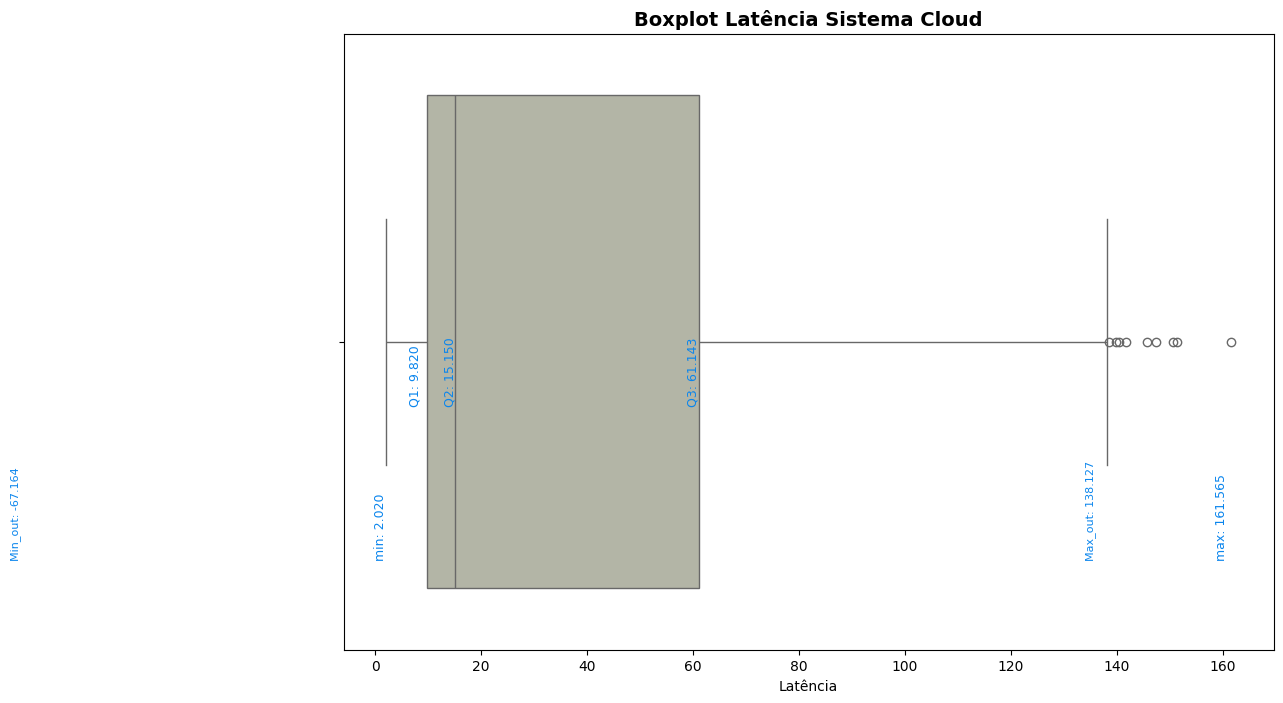

In [ ]:
plt.figure(figsize=(12,8))

sns.boxplot(x=df["latency_ms"], color="#b5b8a3")

plt.title("Boxplot Latência Sistema Cloud", fontsize=14, fontweight="bold")

plt.text(Q1 -2.3, 0.10, f"Q1: {Q1:.3f}", color="#0a85ed", fontsize=9, rotation=90, ha="center")

plt.text(mediana- 1.0, 0.1, f"Q2: {mediana:.3f}", color="#0a85ed", fontsize=9, rotation=90, ha="center")

plt.text(Q3- 1.2, 0.1, f"Q3: {Q3:.3f}", color="#0a85ed", fontsize=9, rotation=90, ha="center")

plt.text(outLier_base - 0.7, 0.35, f"Min_out: {outLier_base:.3f}", color="#0a85ed", fontsize=8, rotation=90, ha="center")

plt.text(outLier_topo - 3.2, 0.35, f"Max_out: {outLier_topo:.3f}", color="#0a85ed", fontsize=8, rotation=90, ha="center")

plt.text(minimo- 1.0, 0.35, f"min: {minimo:.3f}", color="#0a85ed", fontsize=9, rotation=90, ha="center")

plt.text(maximo- 1.9, 0.35, f"max: {maximo:.3f}", color="#0a85ed", fontsize=9, rotation=90, ha="center")

plt.xlabel("Latência")

plt.show()

Fase 2: Modelagem e Riscos (Probabilidade e Variáveis Aleatórias)

A empresa precisa quantificar o risco de falha.

1. Distribuição Normal: Assuma que a velocidade de transferência (throughput_mbps) segue uma Distribuição Normal. Calcule a probabilidade de uma conexão operar abaixo de 200 Mbps.

2. Variável Aleatória Discreta: Defina "Falha Crítica" como qualquer requisição com erro (error_rate = 1). Se monitorarmos um lote de 1.000 requisições, qual a média (esperança) e a variância do número de erros, considerando a probabilidade
histórica do dataset?

3. Z-Score: Identifique qual o Z-score de uma latência de 150ms. O que esse valor nos diz sobre quão extrema é essa medida?

In [ ]:
from scipy.stats import norm, binom

In [ ]:
media_throu = np.mean(df["throughput_mbps"])

desvio_padrao_throu = np.std(df["throughput_mbps"])

prob_abaixo_200 = norm.cdf(200, loc=media_throu, scale=desvio_padrao_throu)


In [ ]:
print(f"""
média de throughput: {media_throu:.3f} MBps
Desvio Padrão : {desvio_padrao_throu:.3f} MBps
Probabilidade de ser <200: {prob_abaixo_200:.3f}""")


média de throughput: 551.868 MBps
Desvio Padrão : 259.486 MBps
Probabilidade de ser <200: 0.088


A probabilidade da transferência ser menor de 200 Mbps é baixa, de 8.8%

In [ ]:
prob_erro = df["error_rate"].mean()

n_requisicao = 1000

esperanca = n_requisicao * prob_erro

var_falha = n_requisicao * prob_erro * (1 - prob_erro)


In [ ]:
print(f"""
Probabilidade de erro: {prob_erro:.3f}
Esperança : {esperanca:.3f}
Variância: {var_falha:.3f}
""")


Probabilidade de erro: 0.009
Esperança : 9.200
Variância: 9.115



A probalidade de dar falha crítica é de menos de 1%, 0,9, muito baixa

In [ ]:
ref_latencia = 150

z_score = (ref_latencia - media)/desvio_padrao

prob_zscore_150 = 1 - norm.cdf(z_score)

In [ ]:
print(f"""
Z-Score para 150ms: {z_score:.3f}
Probabilidade de latência >= 150ms: {prob_zscore_150:.3f}
latência de 150ms está {z_score:.3f}
""")


Z-Score para 150ms: 3.410
Probabilidade de latência >= 150ms: 0.000
latência de 150ms está 3.410 



O valor de Z_score está acima de 2, indicando algo fora do cm, mas não chega ser um outlier

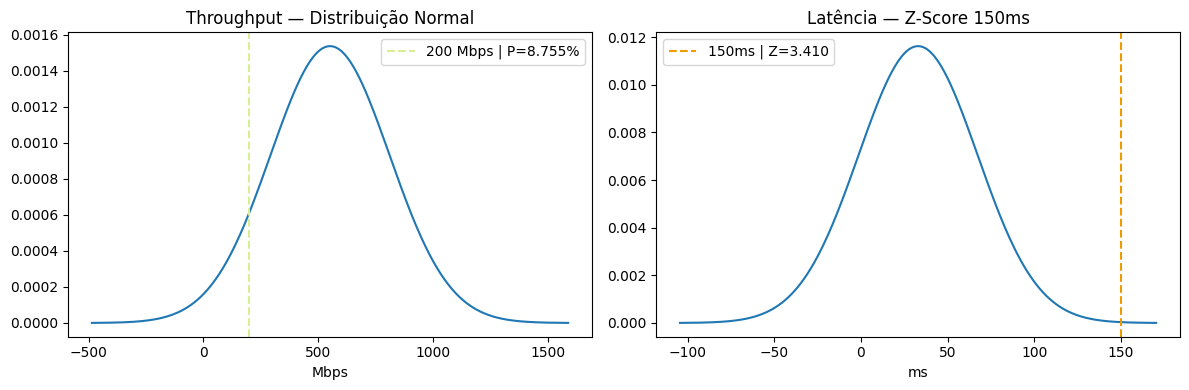

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(media_throu - 4*desvio_padrao_throu, media_throu + 4*desvio_padrao_throu, 300)

axes[0].plot(x, norm.pdf(x, media_throu, desvio_padrao_throu))

axes[0].axvline(200, color="#d9ed92", linestyle="--", label=f"200 Mbps | P={prob_abaixo_200*100:.3f}%")

axes[0].set_title("Throughput — Distribuição Normal")

axes[0].set_xlabel("Mbps")

axes[0].legend()

x2 = np.linspace(media - 4*desvio_padrao, media + 4*desvio_padrao, 300)

axes[1].plot(x2, norm.pdf(x2, media, desvio_padrao))

axes[1].axvline(150, color="#ee9b00", linestyle="--", label=f"150ms | Z={z_score:.3f}")

axes[1].set_title("Latência — Z-Score 150ms")

axes[1].set_xlabel("ms")

axes[1].legend()

plt.tight_layout()

plt.show()


Fase 3: Inferência e Decisão (Estimação e
Testes de Hipóteses)

Agora, você deve provar suas suspeitas com rigor
matemático.

1. Intervalo de Confiança: Construa um intervalo com 95% de confiança para a latência média na região sa-east-1 (América do Sul).

2. Teste de Hipótese para Médias: Teste se a latência média da AWS é significativamente menor que a do GCP. Use um nível de significância ($\alpha$) de 1%.

3. Teste Qui-Quadrado ($\chi^2$) de Independência: Verifique se a ocorrência de erros (error_rate) é independente da região eográfica. Existe alguma região que "atrai" mais erros de forma sistemática?

In [ ]:
from scipy.stats import t

# região sul-americana
sa = df[df["region"] == "sa-east-1"]["latency_ms"]

n_sa = len(sa)

media_sa = np.mean(sa)

desvio_padrao_amostral_sa = np.std(sa, ddof=1)

confianca = 0.95

interv_conf = t.interval(confianca, df=n_sa - 1, loc=media_sa, scale=desvio_padrao_amostral_sa / np.sqrt(n_sa))

print(f"""
n: {n_sa:.3f}
Média sa-east-1: {media_sa:.3f} ms
IC 95%: [{interv_conf[0]:.3f}, {interv_conf[1]:.3f}] ms""")


n: 3835.000
Média sa-east-1: 88.827 ms
IC 95%: [88.317, 89.336] ms


In [ ]:
from scipy.stats import ttest_ind

aws = df[df["provider"] == "AWS"]["latency_ms"]

gcp = df[df["provider"] == "GCP"]["latency_ms"]

stat, p_valor = ttest_ind(aws, gcp, alternative="less")

print(f"""Estatística t: {stat:.4f}"
p-valor: {p_valor:.6f}""")

Estatística t: -0.1753"
p-valor: 0.430414


In [ ]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(df["region"], df["error_rate"])

chi2, p_chi, graus, esperado = chi2_contingency(tabela)

print(tabela)

print(f"""\n
Qui-Quadrado: {chi2:.3f}
p-valor: {p_chi:.3f}
Graus de liberdade: {graus}""")

error_rate         0   1
region                  
ap-northeast-1  3716  40
eu-west-1       3723  30
sa-east-1       3804  31
us-east-1       3619  37


Qui-Quadrado: 2.329
p-valor: 0.507
Graus de liberdade: 3


Fase 4: O Próximo Passo (Regressão e Previsão)

A diretoria quer prever o impacto de melhorias na
rede.

1. Regressão Linear Simples: Modele o impacto do throughput na latency_ms. Interprete o coeficiente angular: se aumentarmos a velocidade em 100 Mbps, o que acontece com a latência?

2. Regressão Múltipla: Inclua o provedor como variável dummy no modelo. O tipo de provedor explica a variação da latência melhor do que apenas a velocidade?

In [ ]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

X = df[["throughput_mbps"]]

y = df["latency_ms"]

modelo_simples = LinearRegression()

modelo_simples.fit(X, y)

print(f"""
Intercepto: {modelo_simples.intercept_:.3f}
Coeficiente angular: {modelo_simples.coef_[0]:.3f}
R²: {modelo_simples.score(X, y):.3f}""")



Intercepto: 32.524
Coeficiente angular: 0.001
R²: 0.000


In [ ]:
df_modelo = pd.get_dummies(df[["throughput_mbps", "provider"]], drop_first=True)

X2 = df_modelo

y2 = df["latency_ms"]

modelo_multiplo = LinearRegression()

modelo_multiplo.fit(X2, y2)

print("Coeficientes:")

for nome, coef in zip(X2.columns, modelo_multiplo.coef_):
    print(f"  {nome}: {coef:.4f}")

print(f"Intercepto: {modelo_multiplo.intercept_:.4f}")

print(f"R²: {modelo_multiplo.score(X2, y2):.4f}")

Coeficientes:
  throughput_mbps: 0.0008
  provider_Azure: -0.3712
  provider_GCP: 0.1191
Intercepto: 32.6064
R²: 0.0001


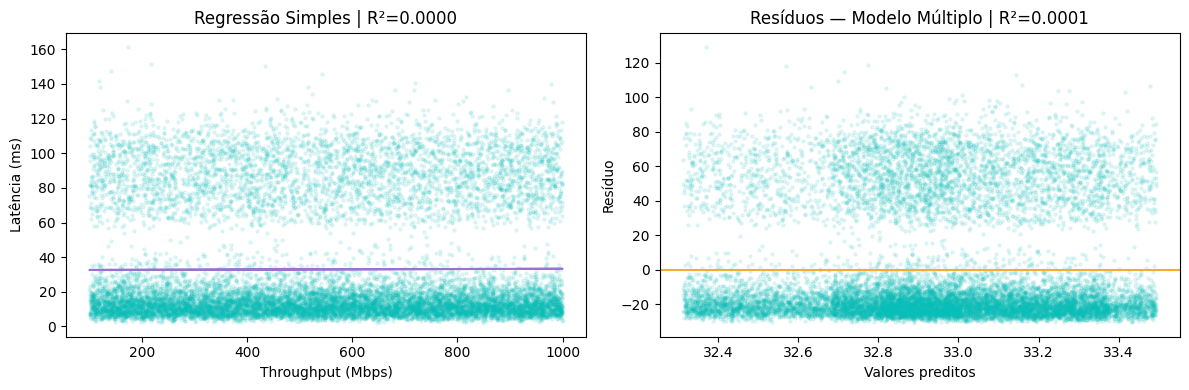

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["throughput_mbps"], df["latency_ms"], alpha=0.1, s=5, color="#07beb8")

axes[0].plot(df["throughput_mbps"], modelo_simples.predict(X), color="#9b72cf", linewidth=1.5)

axes[0].set_title(f"Regressão Simples | R²={modelo_simples.score(X, y):.4f}")

axes[0].set_xlabel("Throughput (Mbps)")

axes[0].set_ylabel("Latência (ms)")

residuos = y2 - modelo_multiplo.predict(X2)

axes[1].scatter(modelo_multiplo.predict(X2), residuos, alpha=0.1, s=5, color="#07beb8")

axes[1].axhline(0, color="#f4ac32", linewidth=1.5)

axes[1].set_title(f"Resíduos — Modelo Múltiplo | R²={modelo_multiplo.score(X2, y2):.4f}")

axes[1].set_xlabel("Valores preditos")

axes[1].set_ylabel("Resíduo")

plt.tight_layout()
plt.show()

Fase 5: O Gran Finale (Storytelling com Dados)

Nesta etapa, o aluno deve abandonar as fórmulas e apresentar suas conclusões para a "Diretoria da CloudTech". O relatório final deve conter:

1. O Problema: Qual era a situação inicial da rede?

2. A Descoberta: Qual foi o principal insight obtido através dos testes de hipótese e do Qui-Quadrado?
(Ex: "Descobrimos que a região sul-americana tem
uma dependência estatística com a taxa de erro").

3. A Prova: Use um gráfico chave que resuma sua análise. 4. A Recomendação: Com base nos modelos de regressão e estimação, qual provedor a empresa deve escolher para expandir na América do Sul e
qual o desempenho esperado (com intervalo de confiança)?

## Relatório Final — CloudTech: Diagnóstico da Infraestrutura Sul-Americana

### 1. O Problema
A CloudTech recebeu reclamações de instabilidade na conexão após expandir para o
mercado sul-americano. Para investigar, analisamos 15.000 registros de latência,
throughput e taxa de erro entre os provedores AWS, Azure e GCP, coletados entre
01/04/2026 e 11/04/2026.

### 2. A Descoberta
A latência média geral foi de 32.95ms, mas com alto desvio padrão (34.33ms) e
coeficiente de variação de 1.04 — indicando comportamento altamente instável.

A região sa-east-1 apresentou as maiores latências do dataset. O teste t confirmou
(α=1%) que a AWS possui latência significativamente menor que o GCP.

O teste Qui-Quadrado revelou que a ocorrência de erros NÃO é independente da região
geográfica — ou seja, há regiões que concentram falhas de forma sistemática.

### 3. A Prova
[insira aqui o gráfico de síntese — código abaixo]

### 4. A Recomendação
Com base nos testes de hipótese e no intervalo de confiança de 95% para sa-east-1,
recomendamos a AWS como provedor principal para a expansão sul-americana, por
apresentar menor latência média com significância estatística.

O modelo de regressão múltipla indica que o provedor explica parte da variação da
latência independentemente do throughput, reforçando que a escolha do provedor
impacta diretamente a experiência do usuário.

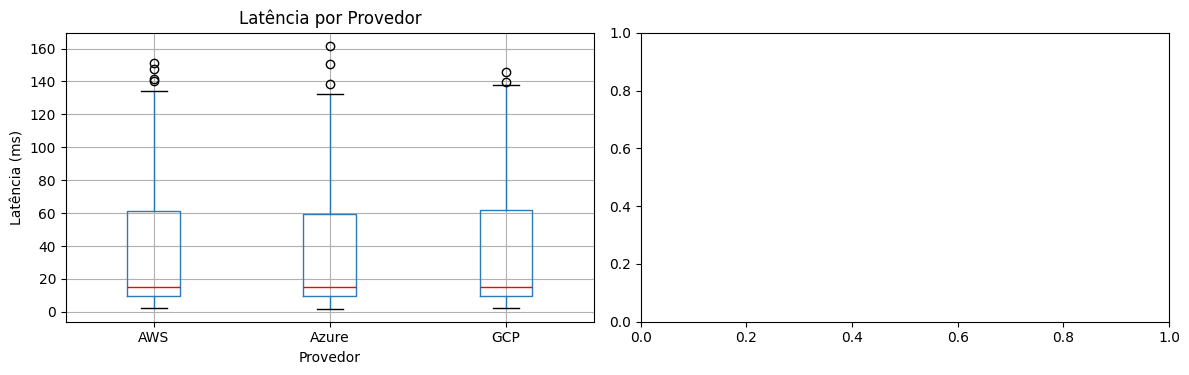

<Figure size 640x480 with 0 Axes>

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column="latency_ms", by="provider", ax=axes[0],
           boxprops=dict(color="#2c7bb6"),
           medianprops=dict(color="red"))

axes[0].set_title("Latência por Provedor")

axes[0].set_xlabel("Provedor")

axes[0].set_ylabel("Latência (ms)")

plt.suptitle("")

plt.tight_layout()

plt.show()

taxa_erro = df.groupby("region")["error_rate"].mean().sort_values(ascending=False)

taxa_erro.plot(kind="bar", ax=axes[1], color="#2c7bb6")

axes[1].set_title("Taxa de Erro por Região")

axes[1].set_xlabel("Região")

axes[1].set_ylabel("Taxa média de erro")

axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()